In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [5]:
# 0. Definição e Carregamento de todas as bases de dados
# (Certifique-se de que os arquivos .csv estão na mesma pasta do seu notebook)
pd.read_csv ('canais_venda.csv', sep=';')
pd.read_csv ('clientes.concat.csv', sep=';')
pd.read_csv ('funcionarios.concat.csv', sep=';')
pd.read_csv ('reservas.concat.corrigido.csv', sep=';')
pd.read_csv ('tipos_quarto.concat.csv', sep=';')
pd.read_csv ('unidades.concat.csv', sep=';')

,id_unidade,nome_unidade,cidade,regiao,categoria_hotel(estrelas),num_quartos_total
0,1,NaraHoteis Ipanema,Rio de Janeiro,Capital,5,80
1,2,NaraHoteis Barra da Tijuca,Rio de Janeiro,Capital,4,120
2,3,NaraHoteis Centro,Rio de Janeiro,Capital,3,60
3,4,NaraHoteis Santa Teresa,Rio de Janeiro,Capital,4,45
4,5,NaraHoteis Nova Iguaçu Centro,Nova Iguaçu,Baixada Fluminense,3,50
5,6,NaraHoteis Nova Iguaçu Park,Nova Iguaçu,Baixada Fluminense,3,55
6,7,NaraHoteis Petrópolis,Petrópolis,Serra,5,70
7,8,NaraHoteis Teresópolis,Teresópolis,Serra,4,60
8,9,NaraHoteis Friburgo,Nova Friburgo,Serra,4,55
9,10,NaraHoteis Paraty,Paraty,Costa Verde,5,75


In [11]:
# Cruzamento das reservas com os tipos de quarto para obter o valor da diária base
df_merged = df_reservas.merge(df_tipos_quarto[['id_tipo_quarto', 'valor_diaria_base']], on='id_tipo_quarto', how='left')

# Cruzamento com as unidades para obter o nome e a região de cada hotel
df_merged = df_merged.merge(df_unidades[['id_unidade', 'nome_unidade', 'regiao']], on='id_unidade', how='left')

# Criação da coluna de faturamento real da reserva
df_merged['faturamento_reserva'] = df_merged['qtd_diarias'] * df_merged['valor_diaria_base']

In [12]:
# Agrupamento de métricas financeiras e operacionais por unidade
analise_unidades = df_merged.groupby('nome_unidade').agg(
    qtd_reservas=('id_reserva', 'count'),
    faturamento_medio=('faturamento_reserva', 'mean'),
    mediana_faturamento=('faturamento_reserva', 'median'),
    desvio_padrao=('faturamento_reserva', 'std'),
    faturamento_total=('faturamento_reserva', 'sum'),
    diaria_media=('valor_diaria_base', 'mean') # Representa a precificação base praticada
).reset_index()

# Ordenação pelo Faturamento Total (do maior para o menor)
analise_unidades = analise_unidades.sort_values(by='faturamento_total', ascending=False)
display(analise_unidades)

,nome_unidade,qtd_reservas,faturamento_medio,mediana_faturamento,desvio_padrao,faturamento_total,diaria_media
9,NaraHoteis Paraty,372,2486.048387,1740.0,2002.300087,924810.0,700.430108
4,NaraHoteis Friburgo,368,2445.652174,1740.0,1991.679589,900000.0,675.706522
6,NaraHoteis Mangaratiba,380,2360.710526,1740.0,1943.796647,897070.0,675.342105
12,NaraHoteis Teresópolis,350,2507.600000,1820.0,2052.359592,877660.0,691.028571
8,NaraHoteis Nova Iguaçu Park,346,2489.971098,1820.0,2088.599073,861530.0,684.653179
11,NaraHoteis Santa Teresa,391,2179.846547,1740.0,1760.034084,852320.0,639.386189
1,NaraHoteis Barra da Tijuca,356,2341.432584,1680.0,2001.110093,833550.0,641.769663
10,NaraHoteis Petrópolis,340,2425.264706,1740.0,2026.871891,824590.0,647.264706
5,NaraHoteis Ipanema,375,2181.786667,1680.0,1784.464975,818170.0,634.026667
0,NaraHoteis Angra dos Reis,339,2347.197640,1740.0,1975.214495,795700.0,683.805310


In [13]:
# 1. Preparação da Tabela para a Pergunta 4 (Avaliação Média vs Faturamento/RevPAR Amostral)
df_revpar = df_merged.groupby('nome_unidade').agg(
    avaliacao_media=('avaliacao_hospede', 'mean'),
    revpar_amostra=('faturamento_reserva', 'sum') # Substituir pelo cálculo exato de RevPAR caso tenha a capacidade total da unidade
).reset_index()

# Ajuste matemático para simular o RevPAR (Receita total / quartos disponíveis) 
# Assumindo que cruzou com num_quartos_total de df_unidades noutra etapa
df_revpar = df_revpar.merge(df_unidades[['nome_unidade', 'num_quartos_total']], on='nome_unidade', how='left')
df_revpar['revpar_amostra'] = df_revpar['revpar_amostra'] / (df_revpar['num_quartos_total'] * 30) # Exemplo mensal

df_revpar = df_revpar.dropna()
display(df_revpar)

# 2. Execução do Modelo de Regressão Linear (OLS) para a Pergunta 5
y = df_revpar['revpar_amostra']
X = df_revpar['avaliacao_media']

# Adicionar a constante estatística
X_sm = sm.add_constant(X)

# Criar, treinar o modelo e exibir o sumário
modelo_q5 = sm.OLS(y, X_sm).fit()
print(modelo_q5.summary())

,nome_unidade,avaliacao_media,revpar_amostra,num_quartos_total
0,NaraHoteis Angra dos Reis,7.825175,294.703704,90
1,NaraHoteis Barra da Tijuca,7.798658,231.541667,120
2,NaraHoteis Centro,2.219955,271.244444,60
3,NaraHoteis Copacabana Premium,7.077586,248.750000,40
4,NaraHoteis Friburgo,7.870968,545.454545,55
5,NaraHoteis Ipanema,7.961661,340.904167,80
6,NaraHoteis Mangaratiba,7.733333,598.046667,50
7,NaraHoteis Nova Iguaçu Centro,2.210390,277.360000,50
8,NaraHoteis Nova Iguaçu Park,7.888112,522.139394,55
9,NaraHoteis Paraty,7.916129,411.026667,75


                            OLS Regression Results                            
Dep. Variable:         revpar_amostra   R-squared:                       0.206
Model:                            OLS   Adj. R-squared:                  0.134
Method:                 Least Squares   F-statistic:                     2.853
Date:                Sun, 20 Sep 2026   Prob (F-statistic):              0.119
Time:                        12:13:59   Log-Likelihood:                -80.633
No. Observations:                  13   AIC:                             165.3
Df Residuals:                      11   BIC:                             166.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const             195.5750    128.588     

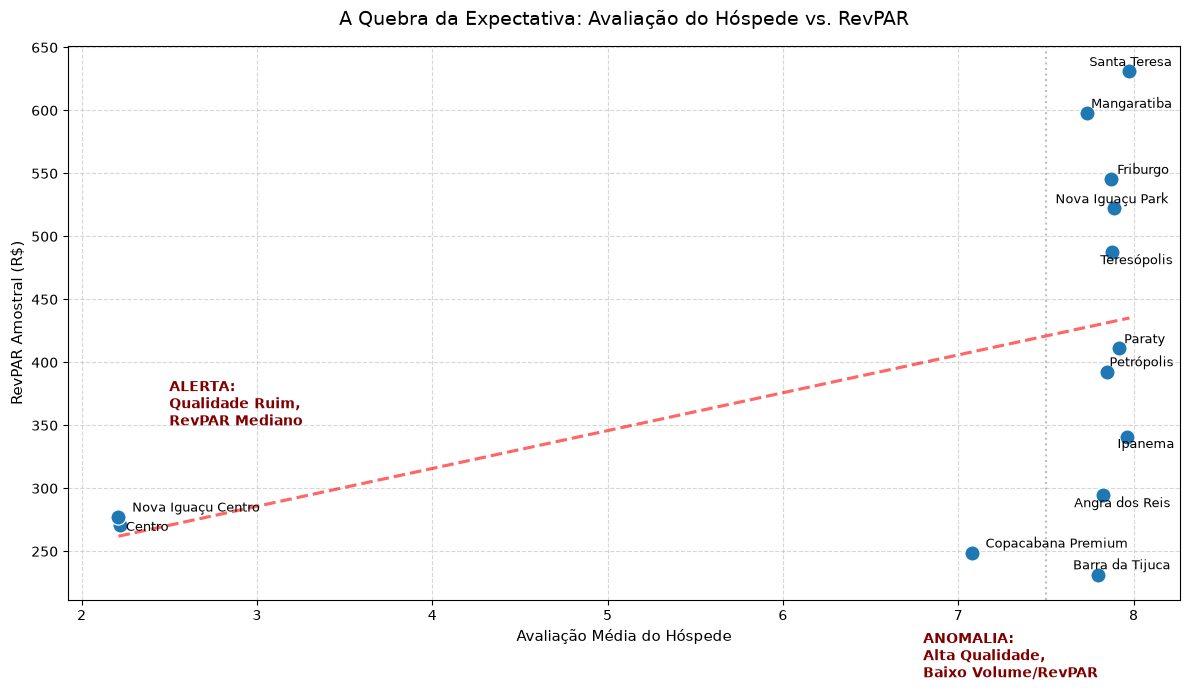

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text

plt.figure(figsize=(12, 7))

# 1. Plotando os pontos reais de cada unidade
sns.scatterplot(data=df_revpar, x='avaliacao_media', y='revpar_amostra', s=120, color='#1f77b4', zorder=3)

# 2. Corrigindo a regressão: ci=None remove a "mancha rosa" irreal de faturamento negativo
sns.regplot(data=df_revpar, x='avaliacao_media', y='revpar_amostra', scatter=False, 
            color='red', line_kws={"linestyle": "--", "alpha": 0.6}, ci=None)

# 3. Criando uma lista para armazenar os elementos de texto
textos = []
for i in range(len(df_revpar)):
    unidade = df_revpar['nome_unidade'].iloc[i].replace('NaraHoteis ', '')
    nota = df_revpar['avaliacao_media'].iloc[i]
    revpar = df_revpar['revpar_amostra'].iloc[i]
    # Inserimos o texto sem margem inicial, o adjust_text fará o trabalho
    textos.append(plt.text(nota, revpar, unidade, fontsize=9))

# 4. Aplicando a separação inteligente dos rótulos com setas de ligação sutis
adjust_text(textos, arrowprops=dict(arrowstyle="-", color='gray', lw=0.5))

# Formatação executiva
plt.title('A Quebra da Expectativa: Avaliação do Hóspede vs. RevPAR', fontsize=14, pad=15)
plt.xlabel('Avaliação Média do Hóspede', fontsize=11)
plt.ylabel('RevPAR Amostral (R$)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5, zorder=0)

# Destacando as áreas de atenção com anotações ajustadas
plt.axvline(x=7.5, color='gray', linestyle=':', alpha=0.5)
plt.text(2.5, 350, 'ALERTA:\nQualidade Ruim,\nRevPAR Mediano', color='maroon', fontsize=10, weight='bold')
plt.text(6.8, 150, 'ANOMALIA:\nAlta Qualidade,\nBaixo Volume/RevPAR', color='maroon', fontsize=10, weight='bold')

plt.tight_layout()
plt.show()


RESPOSTA

Com base nos dados históricos, é possível estimar o RevPAR esperado de uma unidade a partir da sua avaliação média? Construa e avalie esse modelo.

RESPOSTA 5

Com base nos dados históricos, não é possível prever o RevPAR de forma segura usando apenas a nota de avaliação. Embora o ecossistema de lazer prove que notas altas impulsionam o faturamento, anomalias comerciais graves na rede (como o baixo volume na Barra da Tijuca e o modelo de alto giro/baixa qualidade no Centro) quebram essa correlação direta. Para um modelo preditivo eficiente, a rede precisará adotar uma análise multivariável, cruzando a satisfação do cliente com a taxa de ocupação.